In [3]:
import string

import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy import stats
from pathlib import Path
from scipy.stats import kruskal, shapiro, f_oneway, ttest_rel
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

## Data Preprocessing

In [4]:
df_base = pd.read_csv('./data/Attack-A-Results.csv')
df_base.head()

,model,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss
0,1V,0.007276,0.037630,0.023635,NaN,NaN,NaN
1,1V,0.007288,0.035751,0.022651,NaN,NaN,NaN
2,1V,0.007914,0.038026,0.024476,NaN,NaN,NaN
3,1V,0.008287,0.040250,0.026018,NaN,NaN,NaN
4,1V,0.007602,0.007602,0.007602,NaN,NaN,NaN


In [5]:
df_test = df_base.copy().reset_index(drop=True)

df_test['FGSM_IM_Abs_Increase'] = (
    df_test['FGSM_IM_Loss'] - df_test['Clean_IM_Loss']
)

df_test['FGSM_IM_Rel_Increase'] = (
    df_test['FGSM_IM_Abs_Increase'] / df_test['Clean_IM_Loss'] * 100
)

df_test['BIM_IM_Abs_Increase'] = (
    df_test['BIM_IM_Loss'] - df_test['Clean_IM_Loss']
)

df_test['BIM_IM_Rel_Increase'] = (
    df_test['BIM_IM_Abs_Increase'] / df_test['Clean_IM_Loss'] * 100
)

df_test

,model,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss,FGSM_IM_Abs_Increase,FGSM_IM_Rel_Increase,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase
0,1V,0.007276,0.037630,0.023635,NaN,NaN,NaN,0.030355,417.216227,0.016359,224.852667
1,1V,0.007288,0.035751,0.022651,NaN,NaN,NaN,0.028463,390.557093,0.015363,210.807422
2,1V,0.007914,0.038026,0.024476,NaN,NaN,NaN,0.030112,380.487406,0.016562,209.270618
3,1V,0.008287,0.040250,0.026018,NaN,NaN,NaN,0.031963,385.677892,0.017730,213.940613
4,1V,0.007602,0.007602,0.007602,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
5,1V,0.007812,0.038582,0.024625,NaN,NaN,NaN,0.030769,393.852627,0.016812,215.201957
6,1V,0.007724,0.037606,0.023895,NaN,NaN,NaN,0.029881,386.858940,0.016170,209.349384
7,1V,0.008155,0.039692,0.025702,NaN,NaN,NaN,0.031538,386.745925,0.017547,215.177626
8,1V,0.008127,0.039070,0.025803,NaN,NaN,NaN,0.030943,380.727436,0.017676,217.483794
9,1V,0.007930,0.037863,0.024473,NaN,NaN,NaN,0.029933,377.466323,0.016543,208.606946


In [6]:
df_mean = (
    df_test
        .groupby(['model'], as_index=False)[['Clean_IM_Loss', 'FGSM_IM_Loss', 'BIM_IM_Loss', 'FGSM_IM_Abs_Increase', 'FGSM_IM_Rel_Increase', 'BIM_IM_Abs_Increase', 'BIM_IM_Rel_Increase']]
        .mean()
        .round(3)
        .reset_index()
)

df_mean

,index,model,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,FGSM_IM_Abs_Increase,FGSM_IM_Rel_Increase,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase
0,0,1V,0.008,0.035,0.023,0.027,349.959,0.015,192.469
1,1,2V,0.008,0.033,0.018,0.026,327.180,0.010,126.655


## Plots

In [7]:
model_order = ['1V', '2V']

model_color_map = {
    '1V': 'tab:blue',
    '2V': 'tab:orange',
}

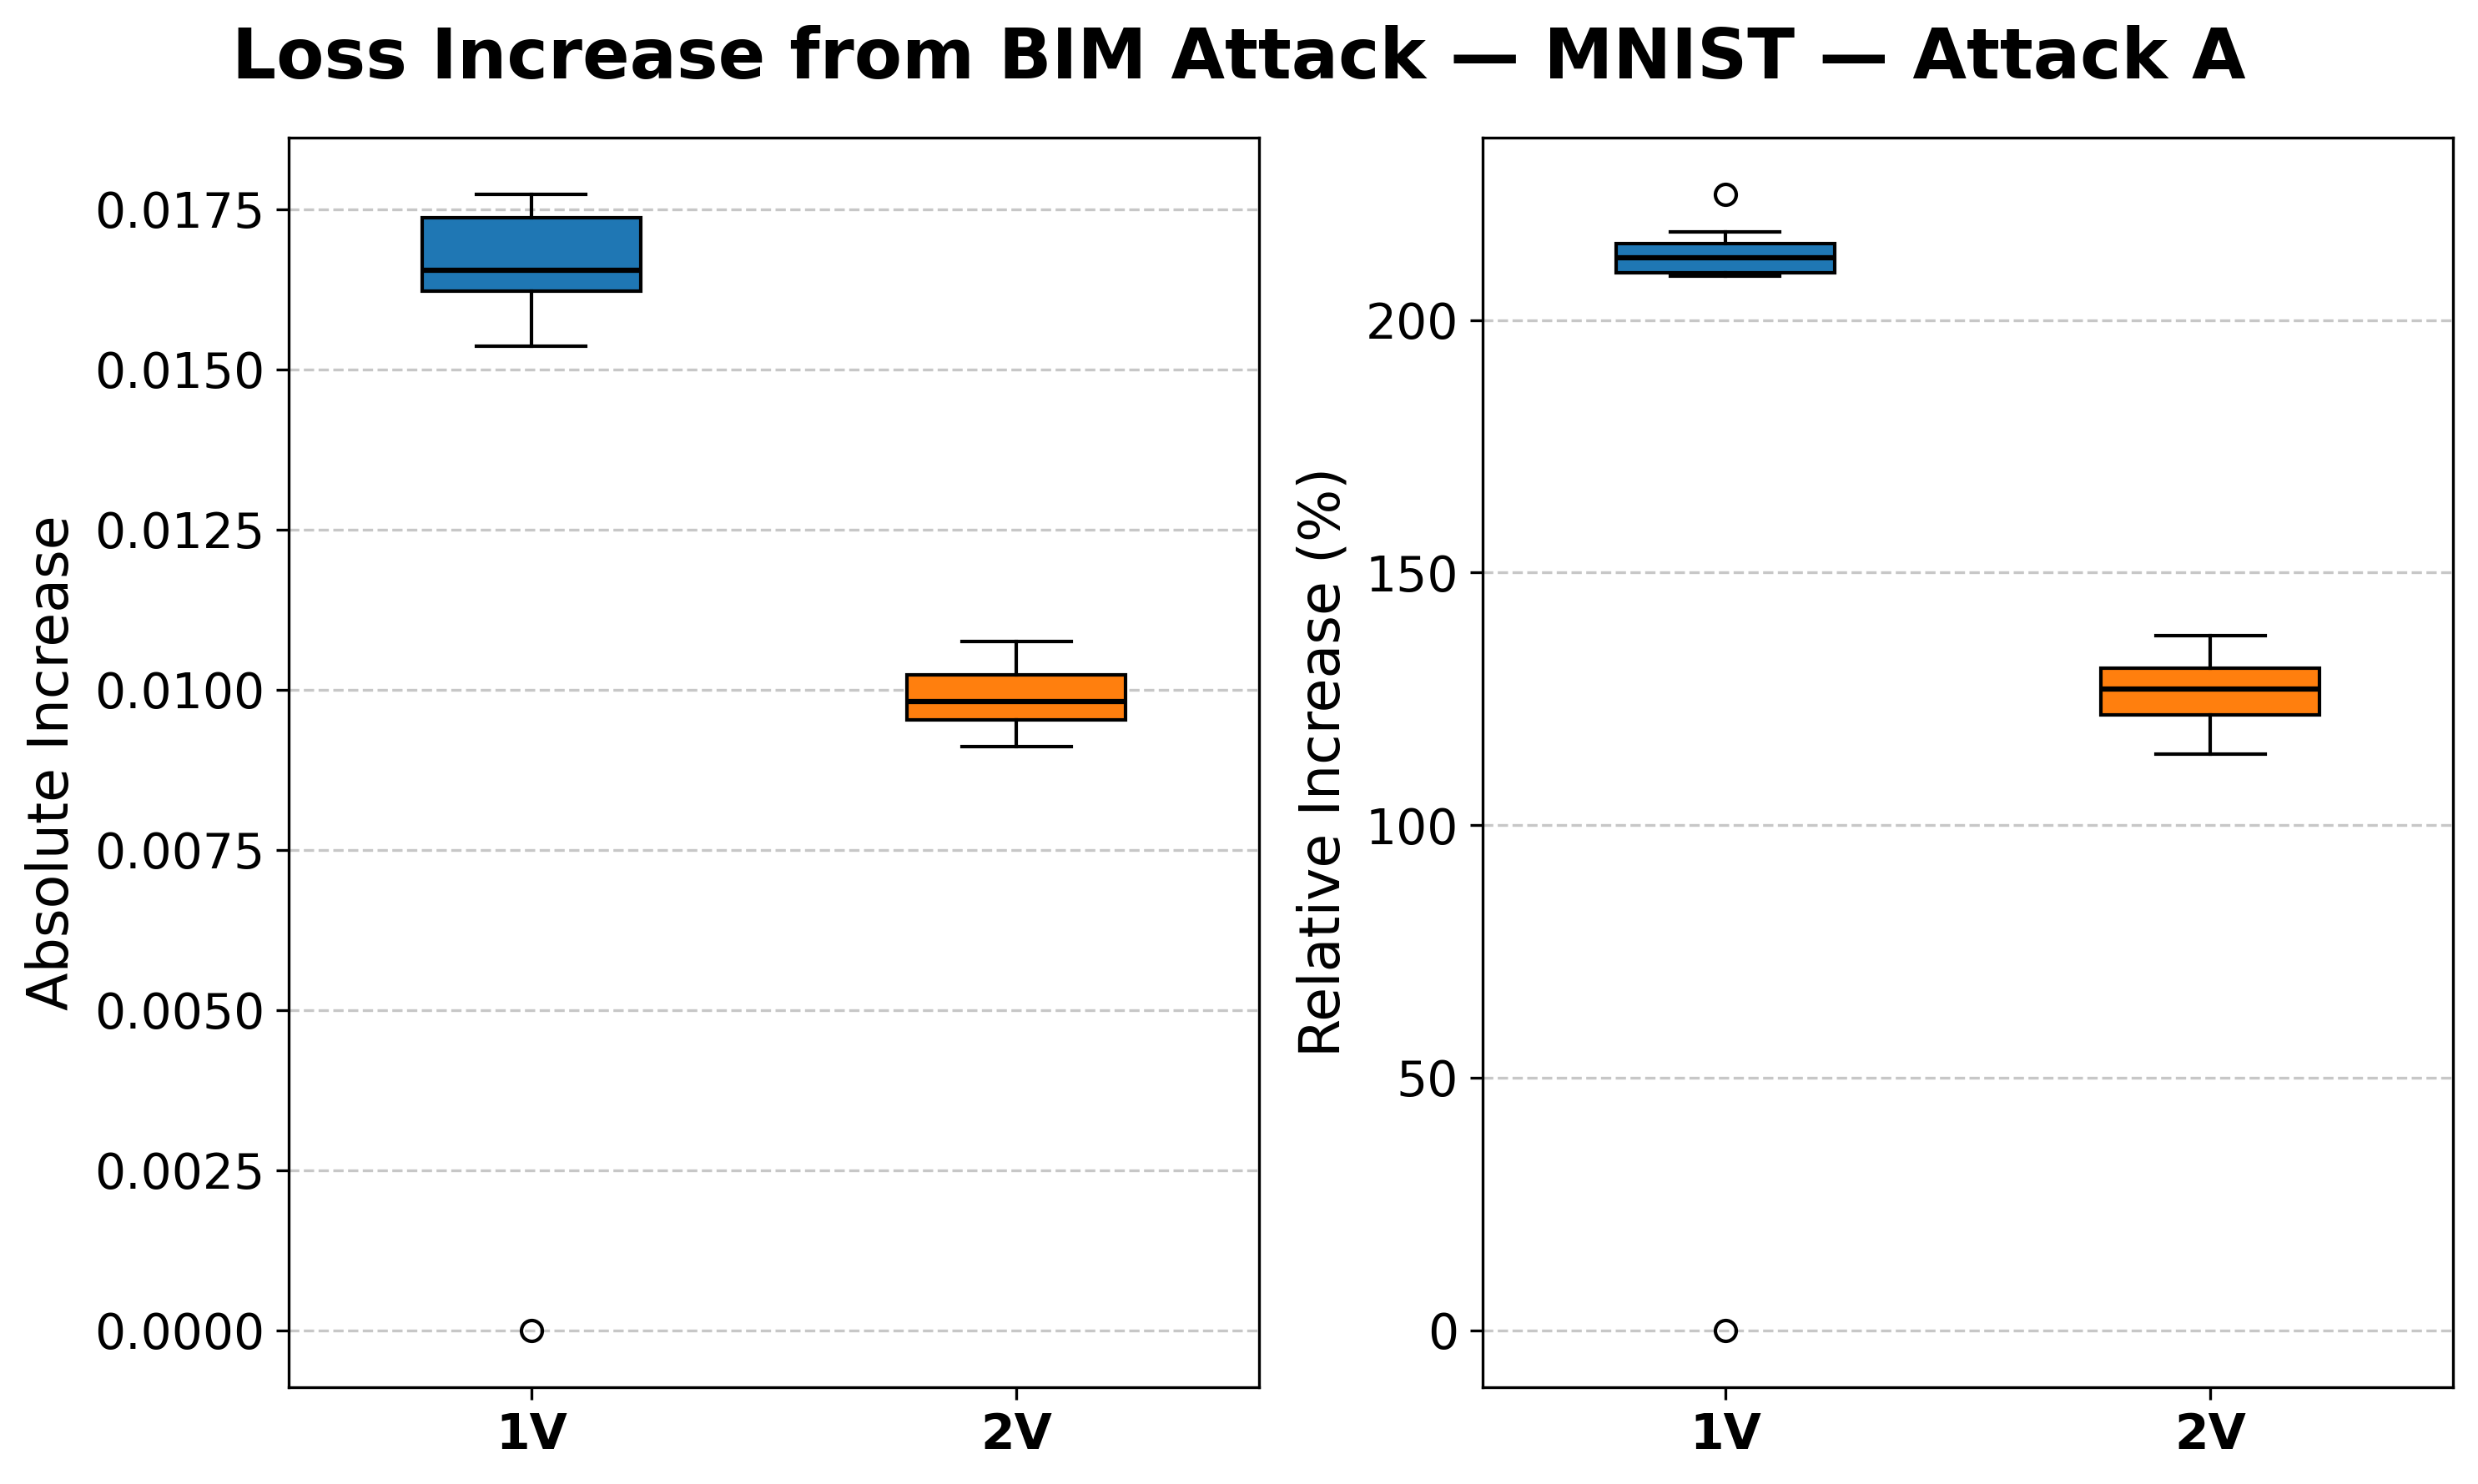

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=300)

plot_specs = [
    (
        'Absolute Increase',
        'Absolute Image Loss Increase',
        'BIM_IM_Abs_Increase',
    ),
    (
        'Relative Increase (%)',
        'Relative Image Loss Increase',
        'BIM_IM_Rel_Increase',
    ),
]

model_positions = np.arange(len(model_order))

for ax, (ylabel, title, col) in zip(axes, plot_specs):
    values = [
        df_test.loc[df_test['model'].eq(model), col].dropna().to_numpy()
        for model in model_order
    ]

    box = ax.boxplot(
        values,
        positions=model_positions,
        widths=0.45,
        patch_artist=True,
        showfliers=True,
    )

    for patch, model in zip(box['boxes'], model_order):
        patch.set_facecolor(model_color_map[model])
        patch.set_edgecolor('black')

    for median in box['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    for whisker in box['whiskers']:
        whisker.set_color('black')

    for cap in box['caps']:
        cap.set_color('black')

    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xticks(model_positions)
    ax.set_xticklabels(model_order, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Loss Increase from BIM Attack — MNIST — Attack A', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./img/attack-A-image-loss-increases-boxplots.png', bbox_inches='tight')
plt.show()

## Statistical Tests - Attacks
### Normality

In [9]:
loss_cols = [
    'Clean_IM_Loss',
    'FGSM_IM_Loss',
    'BIM_IM_Loss',
]

In [10]:
normality_results = []

for col in loss_cols:
    values = df_test[col].dropna()

    stat, p_value = shapiro(values)

    normality_results.append({
        'column': col,
        'n': len(values),
        'W-statistic': stat,
        'p-value': p_value,
        'normal': p_value > 0.05,
    })

normality_df = pd.DataFrame(normality_results)

normality_df

,column,n,W-statistic,p-value,normal
0,Clean_IM_Loss,20,0.914905,0.079090,True
1,FGSM_IM_Loss,20,0.614471,0.000004,False
2,BIM_IM_Loss,20,0.867075,0.010442,False


### Significance

In [14]:
groups = [
    df_test[col].dropna().to_numpy()
    for col in loss_cols
]

h_stat, p_value = kruskal(*groups)

kruskal_results = pd.DataFrame({
    'test': ['Kruskal-Wallis'],
    'columns': [', '.join(loss_cols)],
    'H-statistic': [h_stat],
    'p-value': [p_value],
    'significant': [p_value < 0.05],
})

kruskal_results

,test,columns,H-statistic,p-value,significant
0,Kruskal-Wallis,"Clean_IM_Loss, FGSM_IM_Loss, BIM_IM_Loss",44.369407,2.319026e-10,True


In [15]:
df_long = (
    df_test[loss_cols]
    .melt(var_name='attack', value_name='loss')
    .dropna()
)

# Dunn post-hoc test
dunn_results = sp.posthoc_dunn(
    df_long,
    val_col='loss',
    group_col='attack',
    p_adjust='holm',
)

dunn_results

,BIM_IM_Loss,Clean_IM_Loss,FGSM_IM_Loss
BIM_IM_Loss,1.00000,1.390431e-03,1.390431e-03
Clean_IM_Loss,0.00139,1.000000e+00,8.177878e-11
FGSM_IM_Loss,0.00139,8.177878e-11,1.000000e+00


## Statistical Tests
### Normality

In [11]:
test_cols = [
    'FGSM_IM_Loss',
    'FGSM_IM_Abs_Increase',
    'FGSM_IM_Rel_Increase',
    'BIM_IM_Loss',
    'BIM_IM_Abs_Increase',
    'BIM_IM_Rel_Increase',
]

In [12]:
normality_results = []

for col in test_cols:
    print(f'\n===== {col} =====')

    for model in model_order:
        values = (
            df_test
            .loc[df_test['model'].eq(model), col]
            .dropna()
            .to_numpy()
        )

        w_stat, p_value = shapiro(values)

        normality_results.append({
            'metric': col,
            'model': model,
            'W': w_stat,
            'p': p_value,
            'normal': p_value > 0.05,
        })

        print(f'{model}: W = {w_stat:.4f}, p = {p_value:.4f}')

normality_df = pd.DataFrame(normality_results)
normality_df


===== FGSM_IM_Loss =====
1V: W = 0.4865, p = 0.0000
2V: W = 0.9312, p = 0.4599

===== FGSM_IM_Abs_Increase =====
1V: W = 0.4602, p = 0.0000
2V: W = 0.9208, p = 0.3635

===== FGSM_IM_Rel_Increase =====
1V: W = 0.4472, p = 0.0000
2V: W = 0.8804, p = 0.1318

===== BIM_IM_Loss =====
1V: W = 0.5463, p = 0.0000
2V: W = 0.9391, p = 0.5433

===== BIM_IM_Abs_Increase =====
1V: W = 0.4945, p = 0.0000
2V: W = 0.9696, p = 0.8869

===== BIM_IM_Rel_Increase =====
1V: W = 0.4342, p = 0.0000
2V: W = 0.9831, p = 0.9797


,metric,model,W,p,normal
0,FGSM_IM_Loss,1V,0.486510,2.527659e-06,False
1,FGSM_IM_Loss,2V,0.931215,4.599499e-01,True
2,FGSM_IM_Abs_Increase,1V,0.460177,1.245233e-06,False
3,FGSM_IM_Abs_Increase,2V,0.920785,3.635453e-01,True
4,FGSM_IM_Rel_Increase,1V,0.447238,8.802435e-07,False
5,FGSM_IM_Rel_Increase,2V,0.880376,1.317955e-01,True
6,BIM_IM_Loss,1V,0.546316,1.275680e-05,False
7,BIM_IM_Loss,2V,0.939121,5.432712e-01,True
8,BIM_IM_Abs_Increase,1V,0.494507,3.135787e-06,False
9,BIM_IM_Abs_Increase,2V,0.969575,8.868766e-01,True


### Significance

In [13]:
ttest_results = []

df_paired = df_test.copy()

# Creates pair index: 0, 1, 2, ... separately for each model
df_paired['run'] = df_paired.groupby('model').cumcount()

for col in test_cols:
    wide_df = (
        df_paired
        .pivot(index='run', columns='model', values=col)
        .dropna(subset=model_order)
    )

    t_stat, p_value = ttest_rel(
        wide_df[model_order[0]],
        wide_df[model_order[1]],
        nan_policy='omit',
    )

    ttest_results.append({
        'metric': col,
        'group_1': model_order[0],
        'group_2': model_order[1],
        't': t_stat,
        'p': p_value,
        'significant': p_value < 0.05,
    })

    print(f'\n===== {col} =====')
    print(f'{model_order[0]} vs {model_order[1]}')
    print(f'n pairs: {len(wide_df)}')
    print(f't-statistic: {t_stat:.6f}')
    print(f'p-value: {p_value:.6e}')

ttest_df = pd.DataFrame(ttest_results)
ttest_df


===== FGSM_IM_Loss =====
1V vs 2V
n pairs: 10
t-statistic: 0.620919
p-value: 5.500522e-01

===== FGSM_IM_Abs_Increase =====
1V vs 2V
n pairs: 10
t-statistic: 0.620919
p-value: 5.500522e-01

===== FGSM_IM_Rel_Increase =====
1V vs 2V
n pairs: 10
t-statistic: 0.577036
p-value: 5.780611e-01

===== BIM_IM_Loss =====
1V vs 2V
n pairs: 10
t-statistic: 3.206289
p-value: 1.072257e-02

===== BIM_IM_Abs_Increase =====
1V vs 2V
n pairs: 10
t-statistic: 3.206289
p-value: 1.072257e-02

===== BIM_IM_Rel_Increase =====
1V vs 2V
n pairs: 10
t-statistic: 3.144736
p-value: 1.183742e-02


,metric,group_1,group_2,t,p,significant
0,FGSM_IM_Loss,1V,2V,0.620919,0.550052,False
1,FGSM_IM_Abs_Increase,1V,2V,0.620919,0.550052,False
2,FGSM_IM_Rel_Increase,1V,2V,0.577036,0.578061,False
3,BIM_IM_Loss,1V,2V,3.206289,0.010723,True
4,BIM_IM_Abs_Increase,1V,2V,3.206289,0.010723,True
5,BIM_IM_Rel_Increase,1V,2V,3.144736,0.011837,True
